# _miniML_: tensorflow-based machine learning to detect and analyze miniature and spontaneous synaptic events

Electrophysiology is an instrumental component to the field of neuroscience. Recording electrical activity in real time, whether that's from a single channel, intracellularly, or extracellularly from a population of neurons, requires a way to detect and characterize events of interest as they occur over time. Oftentimes, these events can be small but informative, especially when questions are asked about the spontaneous release of synaptic vesicles and what they say about pre- and post-synaptic properties. Since the signal is so small, robust means to distinguish them from noise are needed.

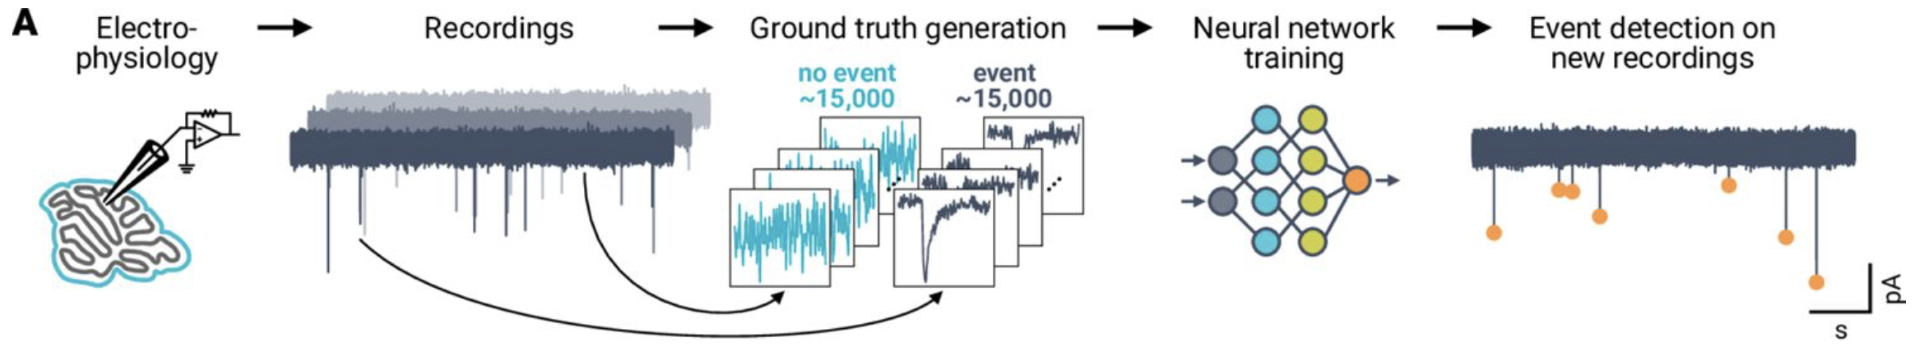

The methodological challenges of patch clamp electrophysiology and the variability between cell types and conditions can make this detection difficult to automate. Current approaches implement a first-derivative approach or template matching algorithms, but in order to preserve the accuracy of their analyses, many researchers label miniature events manually which is both time-consuming, frustrating, and prone to inter-operator variability. Using a convolutional neural network for this task is a novel approach and could cure many headaches over the course of a career. 

miniML (https://github.com/delvendahl/miniML) is a machine-learning based tool for the analysis of miniature and spontaneous electrophysiological recordings with the potential to be applied to other similar data formats like activity-based calcium fluorescence imaging. It was published in 2025 (doi:10.7554/eLife.98485). Today we will investigate its uses and practice its implementation.


### Step 0: Setup

First, we need to set up a virtual environment for miniML. Please refer to the README.md file for detailed instructions.

Once the setup is complete, open this notebook in jupyter lab (make sure you are running miniML environment).

### Optional FYI

While we won't be using it today, the authors of this tool also published a graphical user interface (GUI). There are additional package requirements and some different functionality. As always, running/editing the code yourself grants you more flexibility in your workflow but in case you use this tool in the future or you have labmates with less coding experience, feel free to check it out.

# Example 1: Auditory Cortex sEPSC

## Step 1: Load data



In the first part, we will use patch-clamp recording data from neurons in the auditory cortex. To record EPSCs, the cell is held at around -70 mV in voltage-clamp mode. This holding potential minimizes inhibitory currents and allows us to isolate excitatory synaptic currents. In this example, we analyze spontaneous EPSCs (sEPSCs), not miniature EPSCs (mEPSCs). Since TTX was not applied, the detected events may include both action potential-dependent synaptic activity and spontaneous vesicle release.

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyabf
import h5py
import sys
sys.path.append('../../../miniML/core')  #may need to adjust depending on where you are
from miniML import MiniTrace, EventDetection
from miniML_plot_functions import miniML_plots
%matplotlib qt

Create a MiniTrace object to load the data. Here, we use HDF5 file (.h5), but Axon ABF and HEKA DAT formats are also supported.
The data can be scaled for convenience (e.g., to pA). This is optional and does not affect the analysis. 
Provide the sampling interval (in seconds) of the recording (default is 50 kHz). In this example, the data were recorded at 20 kHz.

In [3]:
filename = "ACx_EPSC_data.h5"

trace = MiniTrace.from_h5_file(
    filename=filename,
    tracename="EPSC_data",
    sampling=5e-5,
    scaling=1e12,
    unit="pA",
)

Let’s plot the loaded data

In [4]:
trace.plot_trace()

Because a 5 mV step was applied to monitor access resistance, a large transient current appears at the beginning of the recording. To remove this artifact, we will trim the data.
Here, we extract the segment from 2 s to 60 s and create the MiniTrace object again.

In [5]:
dt = trace.sampling

i_start = int(2.0 / dt)
i_end   = int(60.0 / dt)

y_cut = trace.data[i_start:i_end]

In [6]:
trace_cut = MiniTrace(
    data=y_cut,                 
    sampling_interval=5e-5,      
    y_unit="pA",         
    filename="VC_Step_1_0"
)

Let's check how it looks now.

In [7]:
trace_cut.plot_trace()

## Step2: Event Detection

Next, we need to create a EventDetection object.
Required arguments are:
- MiniTrace object
- the path to a miniML model file

Optional:
- threshold for event detection can be adjusted (0-1, default:0.5)
- batch_size can be changed to reduce runtime when running on a GPU (caveat: too large batch sizes can cause poor model prediction performance)
- window_size defines the length of the data segment containing a single event. This value needs to match the window size used during model training.

In this example, we will use the base model trained on a large dataset of synaptic events (miniature excitatory postsynaptic currents) recorded from cerebellar mossy fiber-granule cell synapses.

In [8]:
from miniML import EventDetection

model_path = '../../../miniML/models/GC_lstm_model.h5' #may need to adjust

detection = EventDetection(data=trace_cut,
                           model_path=model_path,
                           window_size=600,
                           model_threshold=0.5,
                           batch_size=32,
                           event_direction='negative',
                           compile_model=True,
                           verbose=2)

Model loaded from ../../../miniML/models/GC_lstm_model.h5


To detect events, we need to call the `detect_events()` method.
Set the eval flag to False if you do not want to analyse the detected events. 

For the downstream analysis, four parameters can be adjusted:

- peak_w: int, default = 5. Determines the minimum width of peaks in the prediction trace.
- rel_prom_cutoff: float, default = 0.25. In case multiple peaks in the first derivative are found, this value determines the minimum prominence (relative to the largest prominence) a peak needs to have to be considered an event. For preparations that have no or little to no overlapping events, this value can be set to 1, to find only single peaks.
- convolve_win: int, default = 20. Size of the Hann window used to filter the data for detection of event location and event analysis.
- gradient_convolve_win: int, default = 2*convolve_win (40 here): Size of the Hann window used to filter the first derivative of the filtered data to determine event locations.

convolve_win and gradient_convolve_win are the most crucial to adjust.

In [9]:
detection.detect_events(eval=True,
                        peak_w=5,
                        rel_prom_cutoff=0.25,
                        convolve_win=20,
                        gradient_convolve_win=40)

1812/1812 - 38s - 38s/epoch - 21ms/step

Event statistics:
-------------------------
    Number of events: 94
    Average score: 0.928
    Event frequency: 1.6207 Hz
    Mean amplitude: -15.0354 pA
    Median amplitude: -13.9957 pA
    Std amplitude: 5.6458 pA
    CV amplitude: 0.376
    Mean charge: -0.06976 pC
    CV charge: 0.634
    Mean 10-90 risetime: 1.289 ms
    Mean half decay time: 2.241 ms
    Mean half-width: 12.758 ms
    Tau decay: 3.873 ms
-------------------------


## Step3: Plot the Results

Now that we have computed the event statistics, we can visualize the results!
miniML provides several plotting methods through the `miniML_plots` class.
These methods require a miniML EventDetection object as the data argument.

- `plot_prediction()` shows the model inference trace, optinally together with the data and marked events.

- `plot_event_overlay()` creates a figure with all detected events overlaid, as well as their average and the exponential fit on the average.

- `plot_event_histogram()` plots a histogram of event amplitudes. Set cumulative=True for a cumulative probability plot.

- `plot_gradient_search()` plots the event location search. Top pannel contains the prediction, middle pannel the data and filtered data and lower panel the first derivative and filtered first derivative. Useful if the default filter settings (see above) are not appropriate for your data.

In [12]:
type(detection)

miniML.EventDetection

In [10]:
from miniML_plot_functions import miniML_plots

MiniPlots = miniML_plots(data=detection)

MiniPlots.plot_prediction(include_data=True, plot_filtered_prediction=True, plot_filtered_trace=True, plot_event_params=True)
MiniPlots.plot_event_overlay()
MiniPlots.plot_event_histogram(plot='amplitude', cumulative=False)
MiniPlots.plot_gradient_search()

These are the basic analysis steps!
To recap:
- Step1: Load data (create a `MiniTrace` object )
- Step2: Perform event detection (create an `EventDetection` object and run `detect_events()`)
- Step3: Plot the results using `miniML_plots()`

# Transfer learning model

You can also retrain the model to optimize it for your own data!
Here, we will try to use a transfer learning model to analyze EPSP data.
We freeze the convolutional layers of the base model and train the remaining layers on the mEPSP dataset. This approach greatly reduces both the training time and the amount of data required for training.

## Preparation

We begin by downloading the training dataset for training a miniML mEPSP detection model from Zenodo. The dataset contains labeled data segments of mEPSPs and non-events

In [13]:
import requests

file_url = 'https://zenodo.org/records/14507343/files/2_GC_mepsp_train.h5'

response = requests.get(file_url)

if response.status_code == 200:
    with open('GC_mEPSP_training_data.h5', 'wb') as file:
        file.write(response.content)
    print('Downloaded GC_mEPSP_training_data.h5')

Downloaded GC_mEPSP_training_data.h5


Now we set up our Python environment

In [15]:
import tensorflow as tf
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from tensorflow.keras.layers import (Input, BatchNormalization, AveragePooling1D, Conv1D, 
                                     Bidirectional, LSTM, Dense, Dropout, LeakyReLU)
from tensorflow.keras.optimizers.legacy import Adam
from scipy.signal import resample
import h5py
import numpy as np
import time
import matplotlib.pyplot as plt
import warnings

print('Using TF version', tf.__version__)
print('GPUs available:', len(tf.config.list_physical_devices('GPU')))

Using TF version 2.15.1
GPUs available: 0


## Set training parameters

We set the training parameters in a dictionary called settings.

In [16]:
settings = {
    'training_size': 0.8,
    'testing_size': None,
    'learn_rate': 2e-8,
    'epsilon': 1e-8,
    'patience': 12,
    'epochs': 100,
    'batch_size': 64,
    'dropout': 0.5,
    'training_data': 'GC_mEPSP_training_data.h5',
    'base_model': '../../../miniML/models/GC_lstm_model.h5'
}

## Prepare training data

Now we can start by loading the training dataset. The data is stored in a HDF5 file.

The data is loaded into the x and y variables. The data is resampled to 600 datapoints and the events are inverted. Because the base model was trained to detect downward deflections, inverting the data helps when training on data having a different direction.

In [17]:
with h5py.File(f'{settings["training_data"]}', 'r') as f:
    x = f['events'][:]
    y = f['scores'][:]

fig, axs = plt.subplots(1, 2, figsize=(8,3.5))
axs[0].plot(x[505], c='#425066')
axs[0].set_title('before resampling and inverting\n')

# resample and invert the data
x = resample(x, 600, axis=1)
x *= -1

axs[1].plot(x[505], c='#425066')
axs[1].set_title('after resampling and inverting\n')
plt.tight_layout()
plt.show()

Next, we preprocess the data by applying min-max scaling and splitting it into training and test sets.

In [18]:
#normalization
scaled_data = minmax_scale(x, feature_range=(0,1), axis=1) 

#reshaping for neural network (batch_size, time_points, channels)
scaled_data = np.expand_dims(scaled_data, axis=2) 
merged_y = np.expand_dims(y, axis=1)

print(f'loaded events with shape {scaled_data.shape}')
print(f'loaded scores with shape {merged_y.shape}') 
print(f'ratio of pos/neg scores: {merged_y.sum()/(merged_y.shape[0]-merged_y.sum()):.2f}')

#balance check
if merged_y.sum()/(merged_y.shape[0]-merged_y.sum()) > 1.05:
    warnings.warn("unbalanced dataset: ratio of positive and negative scores >1.05")
elif merged_y.sum()/(merged_y.shape[0]-merged_y.sum()) < 0.95:
    warnings.warn("unbalanced dataset: ratio of positive and negative scores < 0.95")

#train/test split
x_train, x_test, y_train, y_test = train_test_split(scaled_data, merged_y, train_size=settings['training_size'], random_state=1234)

loaded events with shape (4004, 600, 1)
loaded scores with shape (4004, 1)
ratio of pos/neg scores: 1.01


## Prepare the model

In [19]:
def build_model(x_train, dropout_rate):
    model = tf.keras.models.Sequential()
    model.add(Input(shape=(x_train.shape[1:])))
              
    model.add(Conv1D(filters=32, kernel_size=9, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=3, strides=3))
    
    model.add(Conv1D(filters=48, kernel_size=7, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2, strides=2))
    
    model.add(Conv1D(filters=64, kernel_size=5, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    model.add(AveragePooling1D(pool_size=2, strides=2))
    
    model.add(Conv1D(filters=80, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())
    
    model.add(Bidirectional(LSTM(96, dropout=dropout_rate), merge_mode='sum'))
    model.add(Dense(128, activation=LeakyReLU()))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    
    return model

Next, we save the model weights from the pre-trained miniML model (the base model). We then create a new model instance and load the saved weights.

In [20]:
old_model = tf.keras.models.load_model(settings['base_model'], compile=True)
old_model.save_weights('../../../miniML/docs/_data/gc_weights')

new_model = build_model(x_train, settings['dropout'])
new_model.load_weights('../../../miniML/docs/_data/gc_weights')

For transfer learning, we have to freeze the convolutional layers of our model to prevent them from being trained. Only the remaining layers remain trainable.

In [21]:
for ind, layer in enumerate(new_model.layers):
    if layer.name == 'BatchNormalization':
        new_model.layers[ind].trainable = False  #freezing layers
    else:
        if ind < len(new_model.layers) - 4:
            new_model.layers[ind].trainable = False
        else:
            new_model.layers[ind].trainable = True
              
new_model.compile(optimizer=Adam(learning_rate=settings['learn_rate'], epsilon=settings['epsilon'], amsgrad=True),
                  loss=tf.keras.losses.BinaryCrossentropy(),
                  metrics=['Accuracy'])

new_model.summary(show_trainable=True)

Model: "sequential"
____________________________________________________________________________
 Layer (type)                Output Shape              Param #   Trainable  
 conv1d (Conv1D)             (None, 600, 32)           320       N          
                                                                            
 batch_normalization (Batch  (None, 600, 32)           128       N          
 Normalization)                                                             
                                                                            
 leaky_re_lu (LeakyReLU)     (None, 600, 32)           0         N          
                                                                            
 average_pooling1d (Average  (None, 200, 32)           0         N          
 Pooling1D)                                                                 
                                                                            
 conv1d_1 (Conv1D)           (None, 200, 48)           1

## Training

Now we can train our model using the mEPSP dataset. Only the previously selected layers are trained. Because we initialized the model weights from the GC mEPSC base model, training is faster than full model training from scratch.

In [22]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=settings['patience'],
    restore_best_weights=True)

start = time.time()

history = new_model.fit(x_train, y_train,
            verbose=2,
            epochs=settings['epochs'],
            batch_size=settings['batch_size'],
            validation_data=(x_test, y_test),
            shuffle=True,
            callbacks=[early_stopping_callback])

print('')
print('----')
print(f'train shape: {x_train.shape}')
print(f'score on val: {new_model.evaluate(x_test, y_test, verbose=0)[1]}')
print(f'score on train: {new_model.evaluate(x_train, y_train, verbose=0)[1]}')
print('----')
print(f'training time (s): {time.time()-start:.4f}')

Epoch 1/100
51/51 - 8s - loss: 0.2009 - Accuracy: 0.9248 - val_loss: 0.2341 - val_Accuracy: 0.9276 - 8s/epoch - 164ms/step
Epoch 2/100
51/51 - 4s - loss: 0.1677 - Accuracy: 0.9291 - val_loss: 0.2206 - val_Accuracy: 0.9326 - 4s/epoch - 71ms/step
Epoch 3/100
51/51 - 4s - loss: 0.1550 - Accuracy: 0.9347 - val_loss: 0.2079 - val_Accuracy: 0.9351 - 4s/epoch - 70ms/step
Epoch 4/100
51/51 - 4s - loss: 0.1413 - Accuracy: 0.9419 - val_loss: 0.2010 - val_Accuracy: 0.9338 - 4s/epoch - 75ms/step
Epoch 5/100
51/51 - 4s - loss: 0.1425 - Accuracy: 0.9438 - val_loss: 0.1684 - val_Accuracy: 0.9313 - 4s/epoch - 72ms/step
Epoch 6/100
51/51 - 3s - loss: 0.1389 - Accuracy: 0.9410 - val_loss: 0.1695 - val_Accuracy: 0.9363 - 3s/epoch - 68ms/step
Epoch 7/100
51/51 - 3s - loss: 0.1308 - Accuracy: 0.9479 - val_loss: 0.1775 - val_Accuracy: 0.9363 - 3s/epoch - 66ms/step
Epoch 8/100
51/51 - 3s - loss: 0.1392 - Accuracy: 0.9404 - val_loss: 0.1833 - val_Accuracy: 0.9351 - 3s/epoch - 68ms/step
Epoch 9/100
51/51 - 3s 

## Evaluate the model

We can plot the training and validation accuracy and loss curves to assess model performance.

In [23]:
acc = history.history['Accuracy']
val_acc = history.history['val_Accuracy']
epochs = range(1, len(acc) + 1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].plot(epochs, acc, c='#12B5CB', label='Training')
axs[0].plot(epochs, val_acc, c='#425066', label='Validation')
axs[0].set_title('Training and validation accuracy\n')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

loss = history.history['loss']
val_loss = history.history['val_loss']

axs[1].plot(epochs, loss, c='#12B5CB', label='Training')
axs[1].plot(epochs, val_loss, c='#425066', label='Validation')
axs[1].set_title('Training and validation loss\n')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Loss')
axs[1].legend()
plt.tight_layout()
plt.show()

best_epoch = val_acc.index(max(val_acc)) + 1
print(f'Best epoch: {best_epoch} (accuracy={max(val_acc):.4f})')

Best epoch: 22 (accuracy=0.9463)


We can plot the ROC curve and the confusion matrix to further evaluate our trained model.

In [24]:
y_preds = new_model.predict(x_test, verbose=0).ravel()
fpr, tpr, thresholds = roc_curve(y_test, y_preds)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].plot([0, 1], [0, 1], 'y--')
axs[0].plot(fpr, tpr, marker='.')
axs[0].set_xlabel('False positive rate')
axs[0].set_ylabel('True positive rate')
axs[0].set_title('ROC curve\n')

optimal_threshold = thresholds[np.argmax(tpr - fpr)]
y_pred2 = (new_model.predict(x_test, verbose=0) >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=axs[1])
axs[1].set_title('Confusion matrix\n')
plt.tight_layout()
plt.show()

print(f'Area under curve, AUC = {auc(fpr, tpr)}')
print(f'Optimal threshold value = {optimal_threshold}')

Area under curve, AUC = 0.9926054318278176
Optimal threshold value = 0.7567920684814453


## Save trained model and training settings

Finally, we save the trained model to an .h5 file and the training settings to a text file.

In [25]:
new_model.save('lstm_transfer.h5')

with open('tl_training_settings.txt', 'w') as text_file:
    text_file.write('\n'.join(f'{i}: {settings[i]}' for i in settings))

/Users/svd/opt/anaconda3/envs/miniML/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Test the model

Let's apply the new model to EPSP data. The workflow is almost the same as the basic steps we learned above. In this example, we will use sEPSP data recorded from auditory cortex neurons.

### Step1: Loading Data

In [26]:
filename = "ACx_EPSP_data.h5"

trace = MiniTrace.from_h5_file(
    filename=filename,
    tracename="EPSP_data",
    sampling=5e-5,
    scaling=1e3,
    unit="mV",
)

In [27]:
trace.plot_trace()

### Step2: Event Detection

In [28]:
model = 'lstm_transfer.h5' #path to the new model
win_size = 1200  #need to adjust depending on event kinetics and sampling rate
threshold = 0.5
event_direction = 'positive'  #may need to change
training_direction = 'negative'

detection = EventDetection(data=trace,
                           model_path=model,
                           window_size=win_size,
                           model_threshold=threshold,
                           batch_size=512,
                           event_direction=event_direction,
                           training_direction=training_direction,
                           compile_model=True,
                           verbose=2)

Model loaded from lstm_transfer.h5


In [29]:
detection.detect_events(eval=True, convolve_win=30, resample_to_600=True)

59/59 - 14s - 14s/epoch - 233ms/step

Event statistics:
-------------------------
    Number of events: 140
    Average score: 0.828
    Event frequency: 2.3179 Hz
    Mean amplitude: 0.4927 mV
    Median amplitude: 0.3207 mV
    Std amplitude: 0.4553 mV
    CV amplitude: 0.924
    Mean charge: 0.01413 pC
    CV charge: 1.326
    Mean 10-90 risetime: 4.676 ms
    Mean half decay time: 9.589 ms
    Mean half-width: 36.221 ms
    Tau decay: 18.726 ms
-------------------------


### Step3: Plot the Results

In [30]:
MiniPlots = miniML_plots(data=detection)

MiniPlots.plot_prediction(include_data=True, plot_filtered_prediction=True, plot_filtered_trace=True, plot_event_params=True)
MiniPlots.plot_event_overlay()
MiniPlots.plot_event_histogram(plot='amplitude', cumulative=False)

What happens if we apply the EPSC base model to this EPSP data?

# Example 2: Nucleus Accumbens Core sIPSCs

## Step 1: prep data

Electrophysiologists will commonly record alternating sweeps of spontaneous activity at different voltages. While voltage-gated sodium channels are blocked by intracellular QX-314 and potassium channels are blocked by intracellular Cs+, holding near the reversal potential of Cl- (-60 mV) or Na+ (+30 mV) isolates the current passing across the membrane to EPSCs and IPSCs, respectively. That means both sEPSC and sIPSC data is contained within the same file, but we need to analyze these separately. Let's start with IPSCs by cropping and concatenating our data to contain only the sections we want.


For the purposes of my data analysis, I've created a library containing a set of functions that will help us prepare .abf data for miniML. Let's import that now.

In [31]:
import abf_splice

Let's use one of these functions to see our .abf file. 

In [32]:
%matplotlib qt
abf_path = r"24925013.abf"
abf_splice.plot_abf_continuous(abf_path, channel=0, gap_s=0.1)


Here is what we're starting with. As you can see, we need to isolate the regions containing IPSCs (upward-deflecting spikes), stitch them together, and adjust their baselines to match.

Segments kept: 8
Total stitched seconds (pre-detrend): 479.664
Mean adaptive trim (ms): 2.0
Max adaptive trim (ms): 2.0


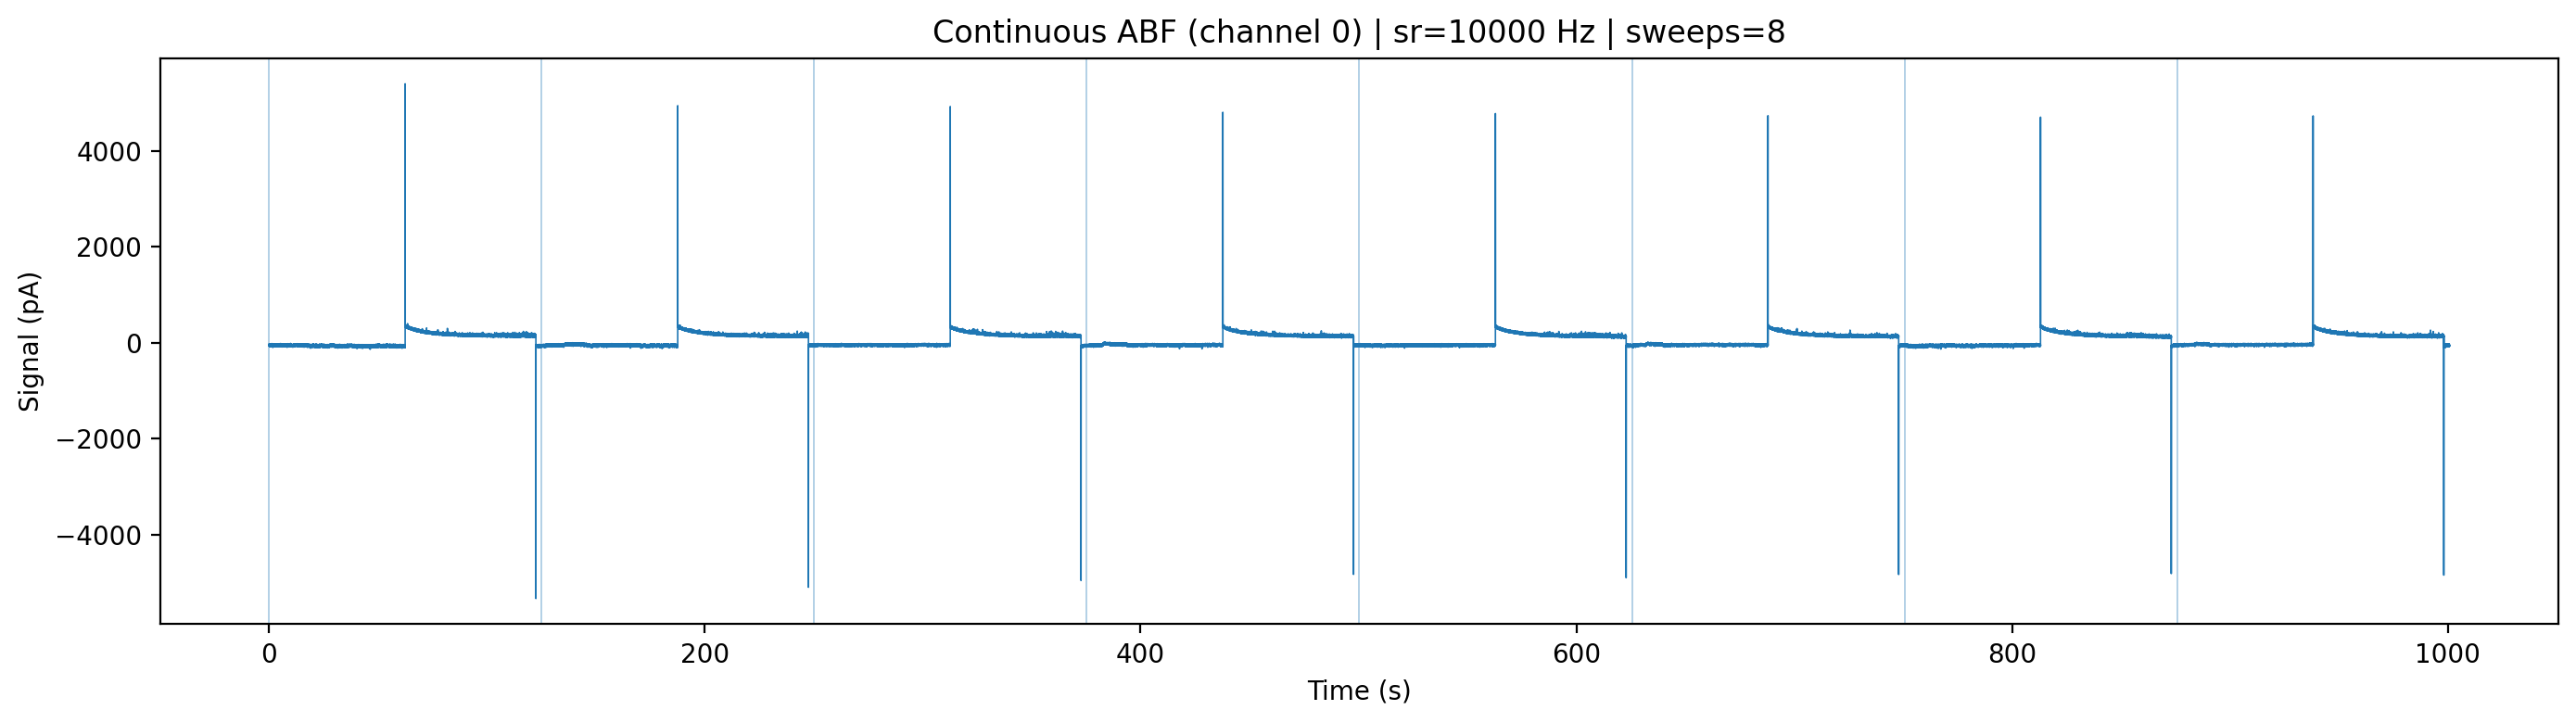

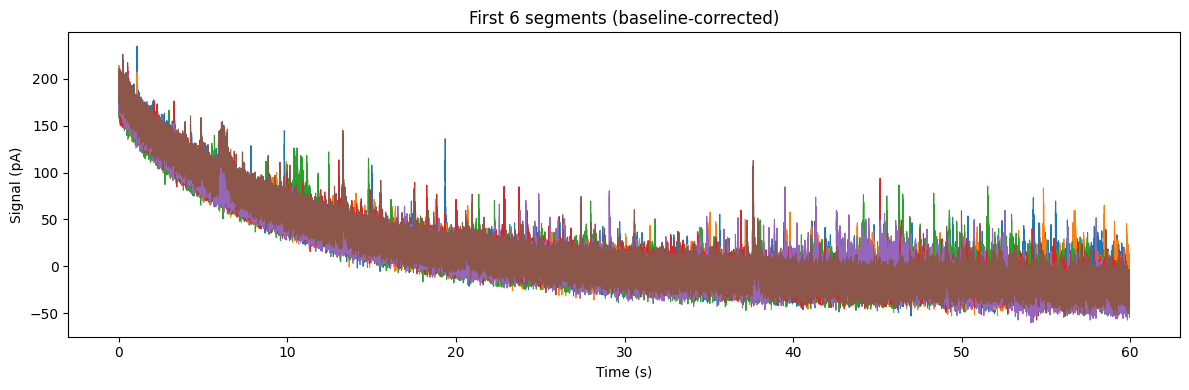

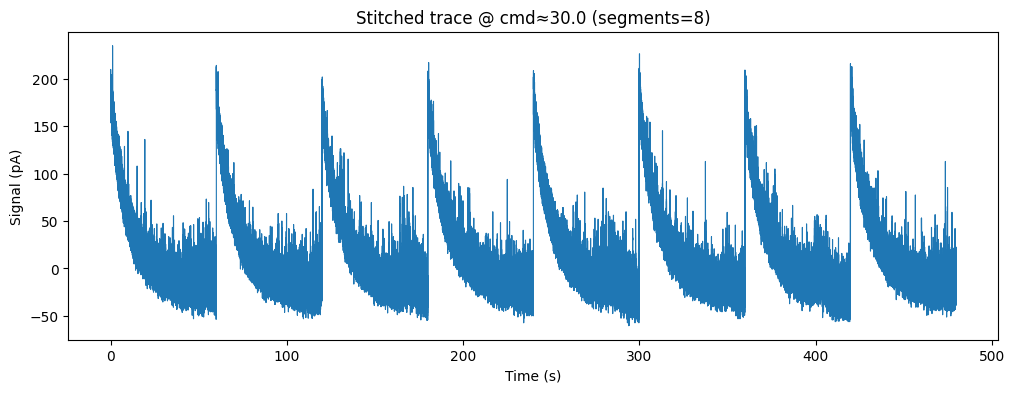

In [33]:
%matplotlib inline
channel = 0

# Choose the command level you want to analyze
target_cmd = 30.0   # mV (typical VC holding) OR pA in CC depending on protocol
cmd_tol = 0.5        # allow small deviation
cmd_quant = 0.05     # quantization step; lower to 0.01 if needed

segments, meta = abf_splice.extract_segments_across_sweeps(
    abf_path=abf_path,
    channel=channel,
    target_cmd=target_cmd,
    cmd_tol=cmd_tol,
    cmd_quant=cmd_quant,
    edge_buffer_s=0.02,
    min_len_s=0.10,
    baseline_method="median",
    transient_correction="adaptive_trim",
    adaptive_min_trim_s=0.002,  # 2 ms enforced minimum
)

print("Segments kept:", len(segments))
print("Total stitched seconds (pre-detrend):", sum(s.size for s in segments)/meta["sample_rate_hz"])

trim_s = [row["trim_s"] for row in meta["segment_table"]]
print("Mean adaptive trim (ms):", 1000 * sum(trim_s) / len(trim_s))
print("Max adaptive trim (ms):", 1000 * max(trim_s))

abf_splice.plot_segment_diagnostics(segments, meta, max_segments=6)

t_stitched, y_stitched = abf_splice.stitch_segments(segments, meta["sample_rate_hz"])

# Optional drift removal 
#y_stitched = abf_splice.detrend_linear(t_stitched, y_stitched)

plt.figure(figsize=(12,4))
plt.plot(t_stitched, y_stitched, lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel(f"Signal ({meta['units']})" if meta["units"] else "Signal")
plt.title(f"Stitched trace @ cmd≈{target_cmd} (segments={len(segments)})")
plt.show()


Notice those peaks from the capacitive current at the beginning of each segment? We are currently using an adaptive method (median absolute deviation) layered on top of a fixed buffer to trim off these tails but we also don't want to lose too much of our data in the process. What about if we fit each segment to an exponential decay curve and subtract it?


Segments kept: 8
Total stitched seconds (pre-detrend): 479.664
Mean adaptive trim (ms): 2.0
Max adaptive trim (ms): 2.0


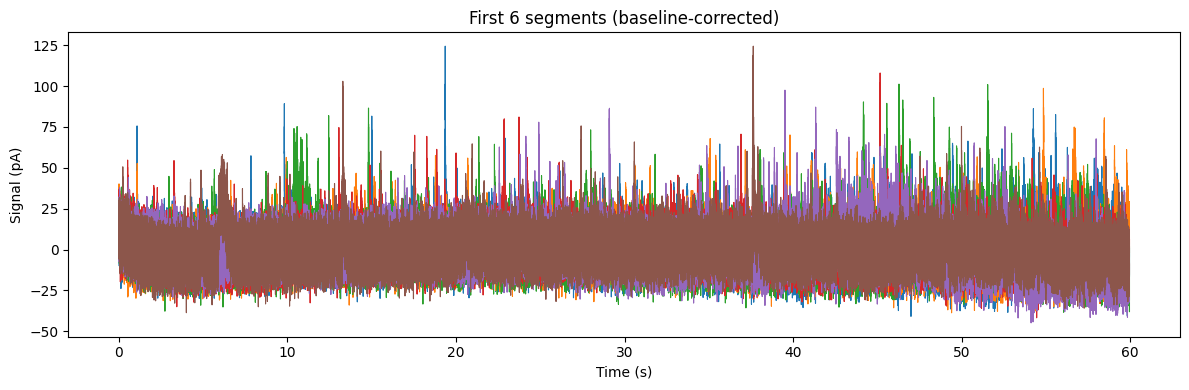

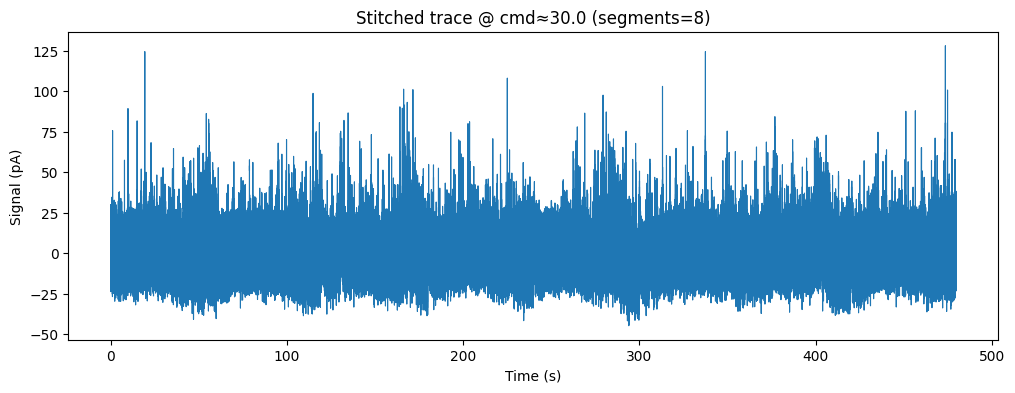

In [34]:
segments, meta = abf_splice.extract_segments_across_sweeps(
    abf_path=abf_path,
    channel=channel,
    target_cmd=target_cmd,
    cmd_tol=cmd_tol,
    cmd_quant=0.05,
    edge_buffer_s=0.02,
    min_len_s=0.10,
    baseline_method="median",

    # Fast step-transient handling (optional)
    transient_correction="adaptive_trim",
    adaptive_min_trim_s=0.002,
    adaptive_max_trim_s=0.02,

    # Slow 60 s drift correction
    slow_baseline_correction="exp_decay",
    slow_fit_downsample_hz=50.0,     # lower = faster, possibly less precise
    slow_baseline_win_s=1.0,          # baseline envelope window
    slow_baseline_percentile=80.0,    # robust against negative mIPSC events
    slow_baseline_smooth_s=0.2,       # smoothing of baseline envelope
    slow_exp_min_tau_s=2.0,           # lower bound of slow decay tau
    slow_exp_max_tau_s=300.0,         # upper bound of slow decay tau
)

print("Segments kept:", len(segments))
print("Total stitched seconds (pre-detrend):", sum(s.size for s in segments)/meta["sample_rate_hz"])

trim_s = [row["trim_s"] for row in meta["segment_table"]]
print("Mean adaptive trim (ms):", 1000 * sum(trim_s) / len(trim_s))
print("Max adaptive trim (ms):", 1000 * max(trim_s))

abf_splice.plot_segment_diagnostics(segments, meta, max_segments=6)

t_stitched, y_stitched = abf_splice.stitch_segments(segments, meta["sample_rate_hz"])

plt.figure(figsize=(12,4))
plt.plot(t_stitched, y_stitched, lw=0.8)
plt.xlabel("Time (s)")
plt.ylabel(f"Signal ({meta['units']})" if meta["units"] else "Signal")
plt.title(f"Stitched trace @ cmd≈{target_cmd} (segments={len(segments)})")
plt.show()


We can now save this concatenated version of only the +30 mV sweeps for safekeeping.

In [35]:
out_path = abf_splice.default_stitched_h5_path(abf_path, target_cmd)
saved_file = abf_splice.save_stitched_h5(
    output_path=out_path,
    t_stitched=t_stitched,
    y_stitched=y_stitched,
    meta=meta,
)

print("Saved:", saved_file)

Saved: 24925013_cmd30_stitched.h5


Now that our data is prepped, we can load it into the miniML framework for analysis. However, we need to determine the sampling rate for our data to read properly. the `abf` package has a method that may be able to help.

MiniML also wants to know the y-axis scaling factor. Take a look at the converted file we just made and make your best guess, assuming sIPSC amplitudes usually range from 10-100 pA.

In [40]:
abf = pyabf.ABF(abf_path)
abf.sweepCount, abf.sampleRate


(8, 10000)

In [ ]:
abf = pyabf.ABF(abf_path)
#Your answer here


In [42]:
#ANSWER

print("dataRate (Hz):", abf.dataRate)
print("sampling interval (s):", 1 / abf.dataRate)
print("sampling interval (ms):", 1000 / abf.dataRate)

sampling=1 / abf.dataRate
scaling=1
unit ='pA'

dataRate (Hz): 10000
sampling interval (s): 0.0001
sampling interval (ms): 0.1


## Step 2: Load data
Now we will load in the .h5 file containing the sIPSC data we just "prepared", using the correct sampling interval and tracename we found earlier.

In [45]:
%matplotlib qt
tracename='mini_data'
#Your answer here
trace = MiniTrace.from_h5_file(
    filename=saved_file,
    tracename="mini_data",
    sampling=sampling,
    scaling=scaling,
    unit=unit,
)

trace.plot_trace()

In [ ]:
#ANSWER

filename = "24925013_cmd30_stitched.h5"
unit = 'pA'

# get from h5 file
trace = MiniTrace.from_h5_file(filename=filename,
                                  tracename='mini_data',
                                  scaling=scaling,
                                  sampling=sampling,
                                  unit=unit)

trace.plot_trace()

## Step 3: Run the model

Now let's create the EventDetection object. Our loaded data will be the MiniTrace object, and we also need a path to the model. Here we can adjust the window size, event detection threshold, batch size, etc. We also want to make sure we set the direction of the events we're looking for to be correct. Remember, our IPSCs are inwardly flowing Cl- ions.

Copy & paste the code from Example 1, changing parameters appropriately for our new data. Look through the week 7 folder to find what you need.

In [ ]:
#copied from above



In [49]:
type(trace)

miniML.MiniTrace

In [47]:
#ANSWER

win_size = 600
direction = 'positive'

detection = EventDetection(data=trace,
                           model_path='MSN_sIPSC_model.h5',
                           window_size=win_size,
                           model_threshold=0.5,
                           batch_size=512,
                           event_direction=direction,
                           compile_model=True,
                           verbose=2)

Model loaded from MSN_sIPSC_model.h5


Now that we've created our EventDetection object, let's go ahead and call the `detect_events()` method. Here we adjust the minimum peak width, minimum peak prominence (with regard to events with multiple peaks), the size of the Hann windows used to filter the data for detection of event location and event analysis.

Same as above, copy & paste.

In [ ]:
#Your answer here

In [51]:
detection.detect_events?

Signature:
detection.detect_events(
    stride: 'int' = None,
    eval: 'bool' = False,
    resample_to_600: 'bool' = True,
    peak_w: 'int' = 5,
    rel_prom_cutoff: 'float' = 0.25,
    filter_factor: 'float' = 20.0,
    convolve_win: 'int' = 0,
    gradient_convolve_win: 'int' = 0,
) -> 'None'
Docstring:
Wrapper function to perform event detection, extraction and analysis

Parameters
------
stride: int, default = None
    The stride used during prediction. If not specified, it will be set to 1/30 of the window size
eval: bool, default = False
    Whether to evaluate detected events.
resample_to_600: bool, default = True
    Whether to resample the the data to match a 600 point window. Should always be true, unless a model was trained with a different window size.
peak_w: int, default = 5
    The minimum prediction peak width.
rel_prom_cutoff: int, float = 0.25
    The relative prominence cutoff. Overlapping events are separated based on a peak-finding in the first derivative. To be 

In [50]:
#ANSWER

detection.detect_events(eval=True,
                        peak_w=5,
                        rel_prom_cutoff=0.25,
                        convolve_win=20,
                        gradient_convolve_win=40)

469/469 - 104s - 104s/epoch - 223ms/step

Event statistics:
-------------------------
    Number of events: 733
    Average score: 0.882
    Event frequency: 1.5282 Hz
    Mean amplitude: 30.6232 pA
    Median amplitude: 27.5598 pA
    Std amplitude: 14.7225 pA
    CV amplitude: 0.481
    Mean charge: 0.60072 pC
    CV charge: 0.899
    Mean 10-90 risetime: 3.046 ms
    Mean half decay time: 8.334 ms
    Mean half-width: 32.255 ms
    Tau decay: 18.422 ms
-------------------------


## Step 4: Inspect the results

Okay so our statistics indicate we got something but a picture tells a thousand words. Let's graph how we did.


In [52]:
%matplotlib qt
MiniPlots = miniML_plots(data=detection)

MiniPlots.plot_prediction(include_data=True, plot_filtered_prediction=True, plot_filtered_trace=True, plot_event_params=True)
MiniPlots.plot_event_overlay()
MiniPlots.plot_event_histogram(plot='amplitude', cumulative=False)
MiniPlots.plot_gradient_search()

## Step 5: Reflection

So how did we do? You can use the Qt interface to zoom in and pan through the trace. What ideas do you have on how we can improve the accuracy? Go ahead and try them out.

ANSWER

possible answers: change threshold, change window size, change peak width
discuss model training fundamentals
discuss filtering types